<a href="https://colab.research.google.com/github/francji1/01RAD/blob/main/code/01RAD_Ex02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01RAD - Exercise 02: Inference in Simple Linear Regression

Lecture 2 turned the least squares estimates of Lecture 1 into statistical statements: $\widehat{\beta}_0, \widehat{\beta}_1$ are unbiased with variances $\sigma^2(1/n + \overline{x}^2/S_{xx})$ and $\sigma^2/S_{xx}$, $s_n^2$ is unbiased for $\sigma^2$, for normal errors $(n-2)s_n^2/\sigma^2 \sim \chi^2(n-2)$ independently of $\widehat{\beta}_0, \widehat{\beta}_1$, the least squares estimates are BLUE (Gauss–Markov theorem), and the ratios $(\widehat{\beta}_j - \beta_j)/\widehat{\sigma}(\widehat{\beta}_j)$ have the $t(n-2)$ distribution, which gives confidence intervals and tests.

In this exercise we work with the classic `mpg` data set (fuel efficiency of 392 cars from 1970 to 1982). We explore the data, fit the simple regression of fuel efficiency on weight, check the sampling properties from Lecture 2 by simulation, compare the least squares slope with another linear unbiased estimator, and compute confidence intervals and tests by hand and with `statsmodels`. R equivalents are mentioned in brackets.

## Learning goals
- Explore a multivariate data set (summary statistics, correlations, pair plots) before choosing a regression model.
- Verify by simulation that $\widehat{\beta}_1$ is unbiased with variance $\sigma^2/S_{xx}$ and that $(n-2)s_n^2/\sigma^2 \sim \chi^2(n-2)$, independent of $\widehat{\beta}_1$.
- See the Gauss–Markov theorem at work: another linear unbiased estimator of the slope has a larger variance.
- Construct confidence intervals for $\beta_0, \beta_1$ and the tests $H_0: \beta_1 = 0$, $H_0: \beta_0 = 0$, $H_0: \beta_1 = b_1$ by hand and read them off the `statsmodels` summary (`coef`, `std err`, `t`, `P>|t|`, `[0.025 0.975]`).
- Reproduce the confidence intervals and tests of the speed-of-sound example from Lecture 2.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.precision', 4)

## 2. Data: fuel efficiency of cars
The `mpg` data (auto-mpg, UCI repository) describe 398 car models sold in the USA between 1970 and 1982: fuel efficiency in miles per gallon (`mpg`), number of cylinders, engine displacement (cubic inches), `horsepower`, `weight` (lb), `acceleration` (seconds from 0 to 60 mph), `model_year` and `origin` (usa, europe, japan). Six cars have an unknown horsepower; we drop them and keep 392 cars.

In [2]:
url_mpg = 'https://raw.githubusercontent.com/francji1/01RAD/main/data/mpg.csv'
try:
    mpg_raw = pd.read_csv(url_mpg)
except Exception:
    mpg_raw = sns.load_dataset('mpg')          # the same data set ships with seaborn
print(f'Rows: {mpg_raw.shape[0]}, columns: {mpg_raw.shape[1]}')
print('Missing values per column:')
print(mpg_raw.isna().sum().to_string())

cars = mpg_raw.dropna().reset_index(drop=True)
print(f'\nAfter dropping rows with missing values: {cars.shape[0]} cars')
cars.head()

Rows: 398, columns: 9
Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0

After dropping rows with missing values: 392 cars


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
cars.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,392.0,23.4459,7.8050,9.0,17.000,22.75,29.000,46.6
cylinders,392.0,5.4719,1.7058,3.0,4.000,4.00,8.000,8.0
displacement,392.0,194.4120,104.6440,68.0,105.000,151.00,275.750,455.0
horsepower,392.0,104.4694,38.4912,46.0,75.000,93.50,126.000,230.0
weight,392.0,2977.5842,849.4026,1613.0,2225.250,2803.50,3614.750,5140.0
acceleration,392.0,15.5413,2.7589,8.0,13.775,15.50,17.025,24.8
model_year,392.0,75.9796,3.6837,70.0,73.000,76.00,79.000,82.0


## 3. Exploration
Before fitting anything we look at the variables, their correlations and their pairwise scatter plots. Fuel efficiency is strongly negatively correlated with weight, displacement and horsepower, which are in turn strongly correlated with each other (a fact that will matter when we move to several regressors). Weight is the most natural single explanatory variable for a first model.

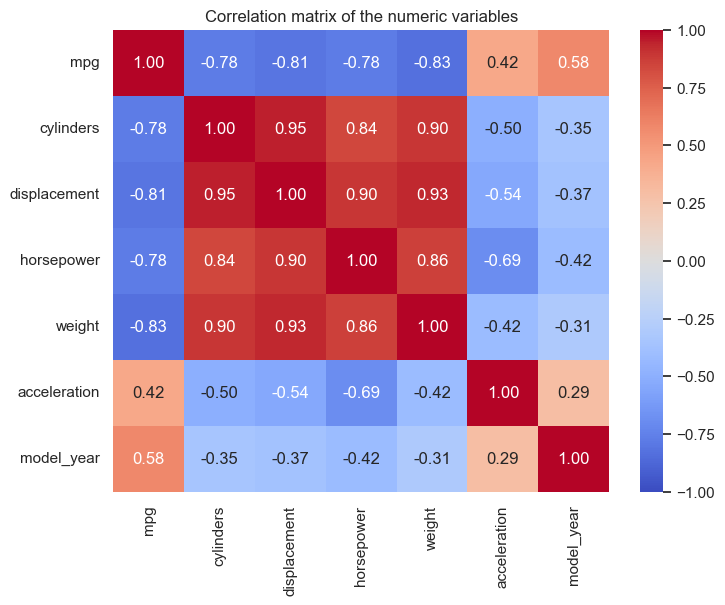

In [4]:
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
corr = cars[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix of the numeric variables')
plt.show()

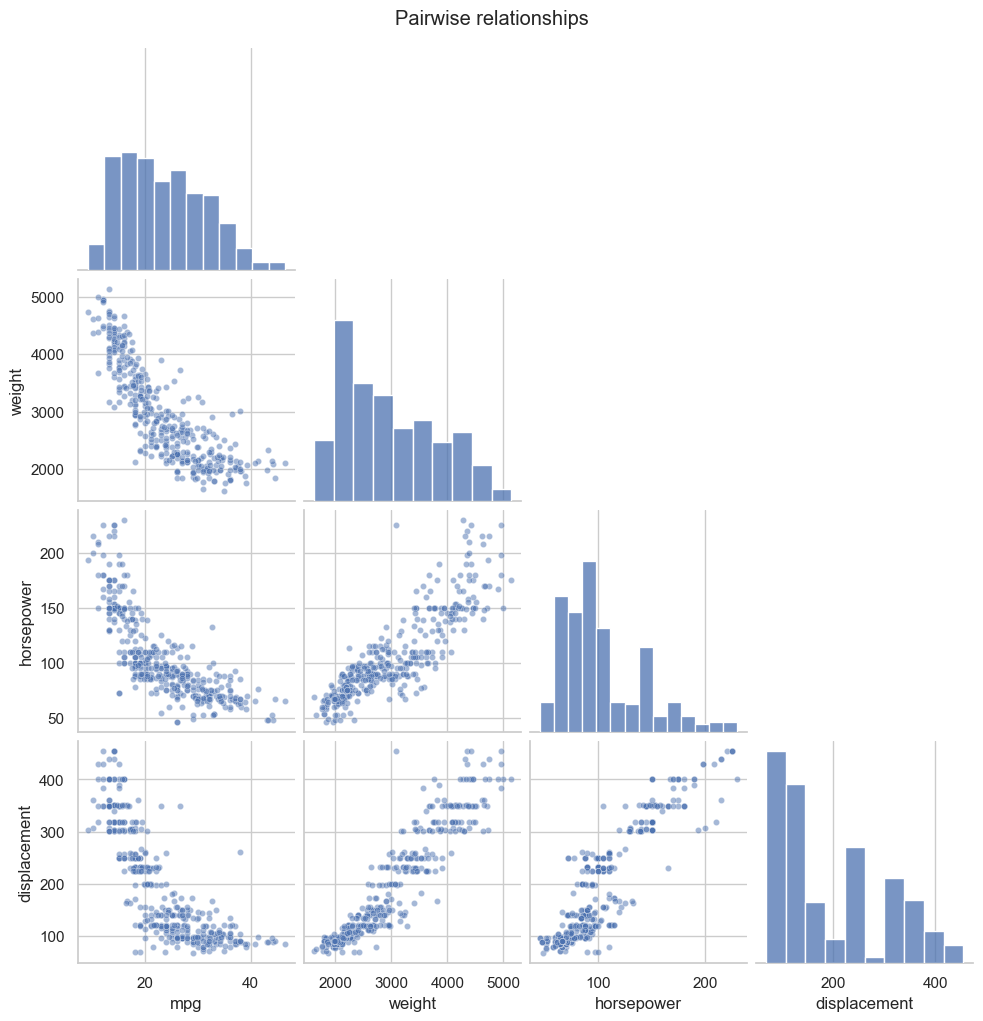

In [5]:
sns.pairplot(cars[['mpg', 'weight', 'horsepower', 'displacement']], corner=True,
             plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Pairwise relationships', y=1.02)
plt.show()

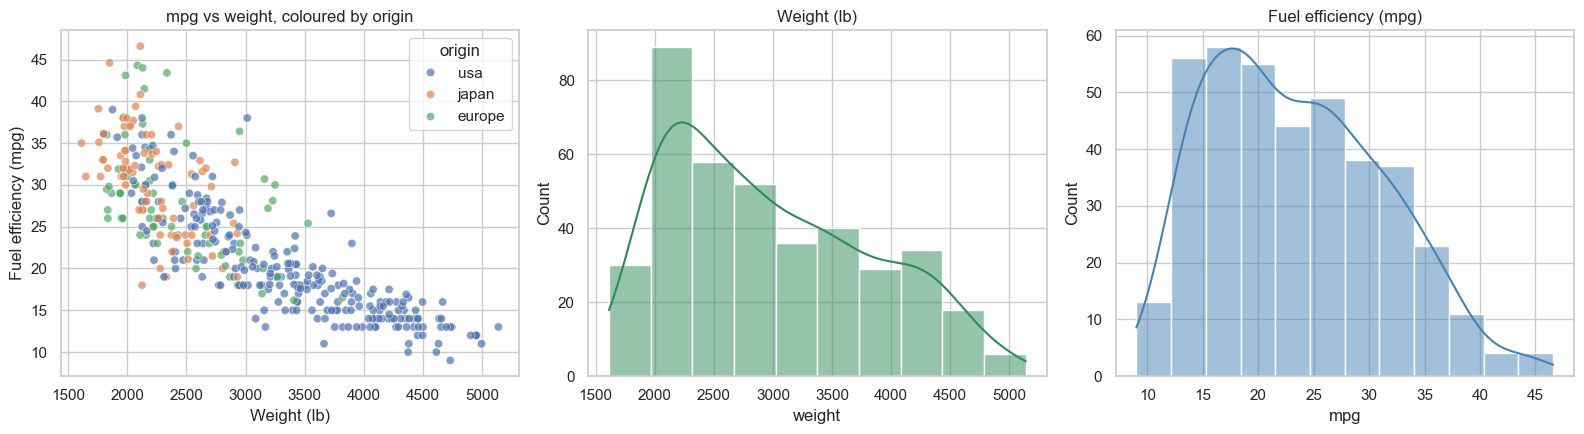

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.scatterplot(data=cars, x='weight', y='mpg', hue='origin', alpha=0.7, ax=axes[0])
axes[0].set_title('mpg vs weight, coloured by origin')
axes[0].set_xlabel('Weight (lb)')
axes[0].set_ylabel('Fuel efficiency (mpg)')
sns.histplot(cars['weight'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Weight (lb)')
sns.histplot(cars['mpg'], kde=True, ax=axes[2], color='steelblue')
axes[2].set_title('Fuel efficiency (mpg)')
plt.tight_layout()
plt.show()

### Group comparison as a warm-up
The colours suggest that cars from the USA are heavier and less efficient. The box plot below shows the whole **distribution** of `mpg` in each group (median and quartiles in the box, whiskers, individual cars as dots) and marks the **mean** of each group with a red diamond. Keep the two things apart: the plot compares distributions, the tests below compare means.

Two classical tools quantify the difference between the group means: a two-sample $t$-test (Welch version, unequal variances) for two groups, and a one-way **ANOVA** $F$-test (analysis of variance; Czech: analýza rozptylu) for the equality of all three means at once. You know both from your course on statistical methods (SME). In this course ANOVA comes back twice: next week as the *ANOVA table of a regression model*, which decomposes the variability of $y$ into the part explained by $x$ and the residual part (Lecture 3), and later when `origin` enters the regression as a **factor** (categorical variable; faktorová proměnná), where the one-way ANOVA turns out to be a special case of a linear model. The general theory is treated in detail in the follow-up course ZLMA (generalized linear models).

In [7]:
by_origin = cars.groupby('origin')['mpg'].agg(['count', 'mean', 'median', 'std'])
by_origin

,count,mean,median,std
origin,,,,
europe,68,27.6029,26.0,6.5802
japan,79,30.4506,31.6,6.0900
usa,245,20.0335,18.5,6.4404


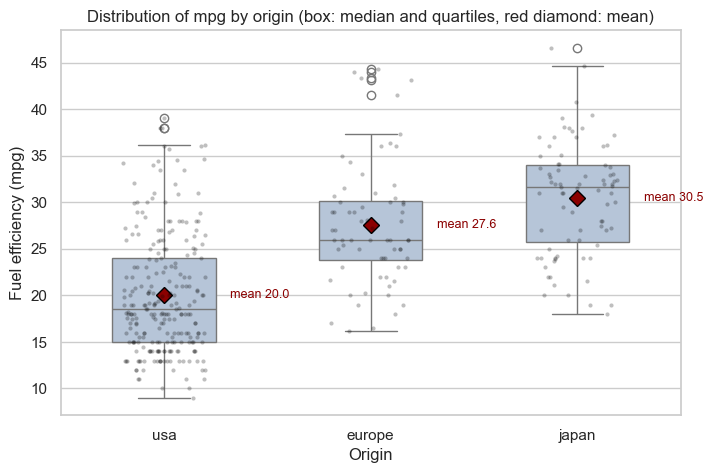

In [8]:
order = ['usa', 'europe', 'japan']
group_means = cars.groupby('origin')['mpg'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=cars, x='origin', y='mpg', order=order, width=0.5, color='lightsteelblue', ax=ax,
            showmeans=True,
            meanprops={'marker': 'D', 'markerfacecolor': 'darkred', 'markeredgecolor': 'black', 'markersize': 8})
sns.stripplot(data=cars, x='origin', y='mpg', order=order, color='black', alpha=0.25, size=3, jitter=0.2, ax=ax)
for i, o in enumerate(order):
    ax.text(i + 0.32, group_means[o], f'mean {group_means[o]:.1f}', va='center', fontsize=9, color='darkred')
ax.set_xlabel('Origin')
ax.set_ylabel('Fuel efficiency (mpg)')
ax.set_title('Distribution of mpg by origin (box: median and quartiles, red diamond: mean)')
plt.show()

In [9]:
usa = cars.loc[cars['origin'] == 'usa', 'mpg']
japan = cars.loc[cars['origin'] == 'japan', 'mpg']
europe = cars.loc[cars['origin'] == 'europe', 'mpg']

welch = stats.ttest_ind(japan, usa, equal_var=False)      # R: t.test(japan, usa)
print(f"Welch two-sample t-test, Japan vs USA : t = {welch.statistic:.2f}, p = {welch.pvalue:.2e}")
anova = stats.f_oneway(usa, japan, europe)                 # R: oneway.test(mpg ~ origin, var.equal = TRUE)
print(f"One-way ANOVA, all three origins      : F = {anova.statistic:.2f}, p = {anova.pvalue:.2e}")

Welch two-sample t-test, Japan vs USA : t = 13.03, p = 7.51e-26
One-way ANOVA, all three origins      : F = 96.60, p = 8.67e-35


## 4. The model: fuel efficiency on weight
We fit the simple linear regression

$$\mathrm{mpg}_i = \beta_0 + \beta_1\, \mathrm{weight}_i + e_i, \qquad i = 1, \dots, 392,$$

with `statsmodels` and recompute the estimates, $s_n$ and the standard errors by hand as in Exercise 01. The slope is negative: every additional pound costs fuel efficiency. Because a pound is a tiny unit, it is easier to read the slope per 1000 lb.

In [10]:
model = smf.ols('mpg ~ weight', data=cars).fit()      # R: mod <- lm(mpg ~ weight, data = cars)

x = cars['weight'].to_numpy(dtype=float)
y = cars['mpg'].to_numpy(dtype=float)
n = len(x)
x_bar, y_bar = x.mean(), y.mean()
S_xx = np.sum((x - x_bar) ** 2)

beta1_hat = np.sum((x - x_bar) * y) / S_xx
beta0_hat = y_bar - beta1_hat * x_bar
resid = y - beta0_hat - beta1_hat * x
SSE = np.sum(resid ** 2)
s_n2 = SSE / (n - 2)
s_n = np.sqrt(s_n2)

delta_0 = 1 / n + x_bar ** 2 / S_xx        # variance multiplication factors (Lecture 2)
delta_1 = 1 / S_xx
se_beta0 = s_n * np.sqrt(delta_0)
se_beta1 = s_n * np.sqrt(delta_1)

pd.DataFrame({
    'quantity': ['beta0_hat', 'beta1_hat', 's_n', 'SE(beta0_hat)', 'SE(beta1_hat)'],
    'manual': [beta0_hat, beta1_hat, s_n, se_beta0, se_beta1],
    'statsmodels': [model.params['Intercept'], model.params['weight'], np.sqrt(model.scale),
                    model.bse['Intercept'], model.bse['weight']],
})

,quantity,manual,statsmodels
0,beta0_hat,46.2165,46.2165
1,beta1_hat,-0.0076,-0.0076
2,s_n,4.3327,4.3327
3,SE(beta0_hat),0.7987,0.7987
4,SE(beta1_hat),0.0003,0.0003


Estimated loss of fuel efficiency per 1000 lb: -7.65 mpg
Standard error of that number            : 0.26 mpg


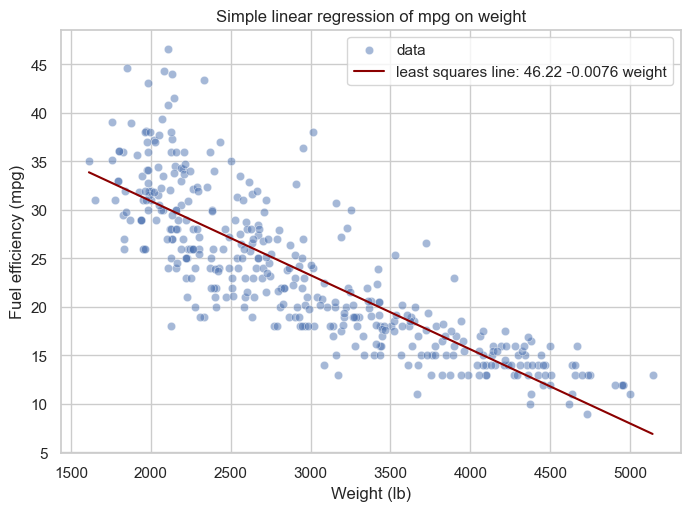

In [11]:
print(f"Estimated loss of fuel efficiency per 1000 lb: {1000 * beta1_hat:.2f} mpg")
print(f"Standard error of that number            : {1000 * se_beta1:.2f} mpg")

plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=cars, x='weight', y='mpg', alpha=0.5, label='data')
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, beta0_hat + beta1_hat * x_line, color='darkred',
         label=f'least squares line: {beta0_hat:.2f} {beta1_hat:+.4f} weight')
plt.xlabel('Weight (lb)')
plt.ylabel('Fuel efficiency (mpg)')
plt.title('Simple linear regression of mpg on weight')
plt.legend()
plt.show()

## 5. Sampling distribution of the estimates by simulation
Lecture 2 proved, for model $(\ast)$ with independent errors $e_i \sim (0, \sigma^2)$:

1. $\mathrm{E}\,\widehat{\beta}_j = \beta_j$ (unbiasedness), $\mathrm{Var}(\widehat{\beta}_1) = \sigma^2/S_{xx}$, $\mathrm{Var}(\widehat{\beta}_0) = \sigma^2 (1/n + \overline{x}^2/S_{xx})$;
2. $\mathrm{E}\, s_n^2 = \sigma^2$;
3. for normal errors $\widehat{\beta}_j \sim N(\beta_j, \mathrm{Var}(\widehat{\beta}_j))$, $(n-2)s_n^2/\sigma^2 \sim \chi^2(n-2)$, and $s_n^2$ is independent of $\widehat{\beta}_0, \widehat{\beta}_1$.

We cannot check these statements on one data set, because we observe one $\widehat{\beta}_1$ only. We can check them on a *known* model: take the fitted line as the truth ($\beta_0 = \widehat{\beta}_0$, $\beta_1 = \widehat{\beta}_1$, $\sigma = s_n$), keep the 392 weights fixed, draw new normal errors many times, refit, and look at the distribution of the estimates across the repetitions.

This is **not a bootstrap**: we do not resample the observed data or the residuals. We generate new data from a model whose parameters we know, so that the simulated distributions can be compared with the theorems of Lecture 2 exactly. The residuals of the real fit enter only through $s_n$, which sets the scale of the simulated errors; each simulated sample is a new hypothetical realisation of the same experiment with the same $x_i$, which is precisely the situation the theorems describe. (Drawing the noise by resampling the observed residuals instead of from $N(0, s_n^2)$ would be the *residual bootstrap*, a tool for inference about real data without assuming normality; it is not part of this course.)

**The cell below is a small laboratory.** Four things can be changed, one at a time, by uncommenting an alternative line: the true parameters, the design $x_i$, the distribution of the errors and the correlation between errors. After a change rerun the cells of sections 5 to 7 and watch the table, the three plots and the coverage of the confidence intervals.

- Choices that respect the assumptions of Theorem 2.1 (any $\beta_0, \beta_1$, any $\sigma$, any design, normal errors) confirm all five statements; the $\beta$'s only shift the estimates, $\sigma$ and $S_{xx}$ set the spread.
- Choices that keep $\mathrm{E}\,e_i = 0$ and $\mathrm{Var}(e_i) = \sigma^2$ but drop normality (uniform, Laplace or $t_3$ errors) keep unbiasedness, the variance formula and $\mathrm{E}\,s_n^2 = \sigma^2$, the Gauss–Markov part. The $\chi^2$ law for $s_n^2$ breaks clearly (too narrow for uniform, too wide for Laplace, wildly off for $t_3$), while $\widehat{\beta}_1$ stays approximately normal by the central limit theorem and the $t$-intervals still cover the true value about 95 % of the time; the exact independence of $\widehat{\beta}_1$ and $s_n^2$ is lost, but with $n = 392$ this is hard to see in the scatter plot, try it with the small design.
- Choices that violate the basic assumptions (variance growing with $x$, correlated errors, errors with non-zero mean) break the variance formula or introduce bias, and the intervals of section 7 stop covering the true value 95 % of the time.

The table compares the simulated means and standard deviations with the theoretical values; the plots compare the histograms with the $N(\beta_1, \sigma^2/S_{xx})$ and $\chi^2(n-2)$ densities. (Under normality $\mathrm{Var}(s_n^2) = 2\sigma^4/(n-2)$, which gives the theoretical sd of $s_n^2$ in the table.)

In [12]:
# ================= Simulation settings: change ONE thing at a time, then rerun this cell and the cells below =================
rng = np.random.default_rng(2026)
reps = 5000

# (1) "true" parameters. Any values work, the theorems do not depend on them.
beta0_true = beta0_hat          # try: 0.0 or 100.0    -> only shifts beta0_hat, nothing else changes
beta1_true = beta1_hat          # try: 0.0 or -0.02    -> only shifts beta1_hat, nothing else changes
sigma_true = s_n                # try: 2.0 or 10.0     -> spread of beta_hat and of s_n^2 scales with sigma

# (2) design: the x_i used in every simulated sample. The theorems hold for any fixed design; S_xx sets the precision.
x_design = x                                                        # all 392 weights
# x_design = x[(x > 2000) & (x < 3000)]                             # narrow range of weights: S_xx small, beta1_hat much more spread out, still unbiased
# x_design = np.sort(rng.choice(x, size=20, replace=False))         # small sample n = 20: chi2(n-2) skewed, t(n-2) visibly wider than the normal

# (3) error distribution. Points 1 and 2 of Theorem 2.1 need only E e_i = 0 and Var(e_i) = sigma^2;
#     point 3 (normality of beta_hat, chi2 for s_n^2, independence) needs normal errors.
def draw_errors(shape):
    return rng.normal(0.0, sigma_true, size=shape)                                        # normal: all five statements hold
    # return rng.uniform(-np.sqrt(3) * sigma_true, np.sqrt(3) * sigma_true, size=shape)   # uniform, same variance: 1, 2 hold; beta1_hat ~ normal by CLT; chi2 too narrow
    # return rng.laplace(0.0, sigma_true / np.sqrt(2), size=shape)                        # Laplace, same variance: 1, 2 hold; chi2 too wide
    # return rng.standard_t(3, size=shape) * sigma_true / np.sqrt(3)                      # t(3), heavy tails, same variance: 1, 2 hold; chi2 wildly off; dependence of beta1_hat and s_n^2 visible only for small n
    # return rng.normal(0.0, sigma_true, size=shape) * (x_design / x_design.mean())       # heteroscedastic (sd grows with weight): unbiased, but Var formula wrong, intervals miss
    # return rng.normal(0.0, sigma_true, size=shape) + 3.0                                # mean 3 instead of 0: beta0_hat biased by +3, beta1_hat unaffected

# (4) correlation of neighbouring errors (in the order of the data). The theorems assume rho = 0.
rho = 0.0                       # try: 0.7 -> correlated errors: still unbiased, but the variance formula and the intervals fail
# ===================================================================================================================================

n_sim = len(x_design)
x_bar_sim = x_design.mean()
S_xx_sim = np.sum((x_design - x_bar_sim) ** 2)
delta_0_sim = 1 / n_sim + x_bar_sim ** 2 / S_xx_sim
delta_1_sim = 1 / S_xx_sim

E = draw_errors((reps, n_sim))                       # errors e_i, one row per simulated sample
if rho != 0.0:                                       # AR(1) dependence along the data order, same marginal variance
    for j in range(1, n_sim):
        E[:, j] = rho * E[:, j - 1] + np.sqrt(1 - rho ** 2) * E[:, j]
Y_sim = beta0_true + beta1_true * x_design + E       # the same x_i in every sample

x_c = x_design - x_bar_sim
b1_sim = (Y_sim @ x_c) / S_xx_sim                    # slope of every sample at once
b0_sim = Y_sim.mean(axis=1) - b1_sim * x_bar_sim
resid_sim = Y_sim - b0_sim[:, None] - b1_sim[:, None] * x_design
s_n2_sim = np.sum(resid_sim ** 2, axis=1) / (n_sim - 2)

print(f"n = {n_sim}, S_xx = {S_xx_sim:.3e}, {reps} simulated samples")
pd.DataFrame({
    'quantity': ['beta0_hat', 'beta1_hat', 's_n^2'],
    'true value': [beta0_true, beta1_true, sigma_true ** 2],
    'mean over simulations': [b0_sim.mean(), b1_sim.mean(), s_n2_sim.mean()],
    'theoretical sd': [sigma_true * np.sqrt(delta_0_sim), sigma_true * np.sqrt(delta_1_sim), sigma_true ** 2 * np.sqrt(2 / (n_sim - 2))],
    'sd over simulations': [b0_sim.std(ddof=1), b1_sim.std(ddof=1), s_n2_sim.std(ddof=1)],
})

n = 392, S_xx = 2.821e+08, 5000 simulated samples


,quantity,true value,mean over simulations,theoretical sd,sd over simulations
0,beta0_hat,46.2165,46.2230,0.7987,0.7813
1,beta1_hat,-0.0076,-0.0076,0.0003,0.0003
2,s_n^2,18.7724,18.7699,1.3443,1.3366


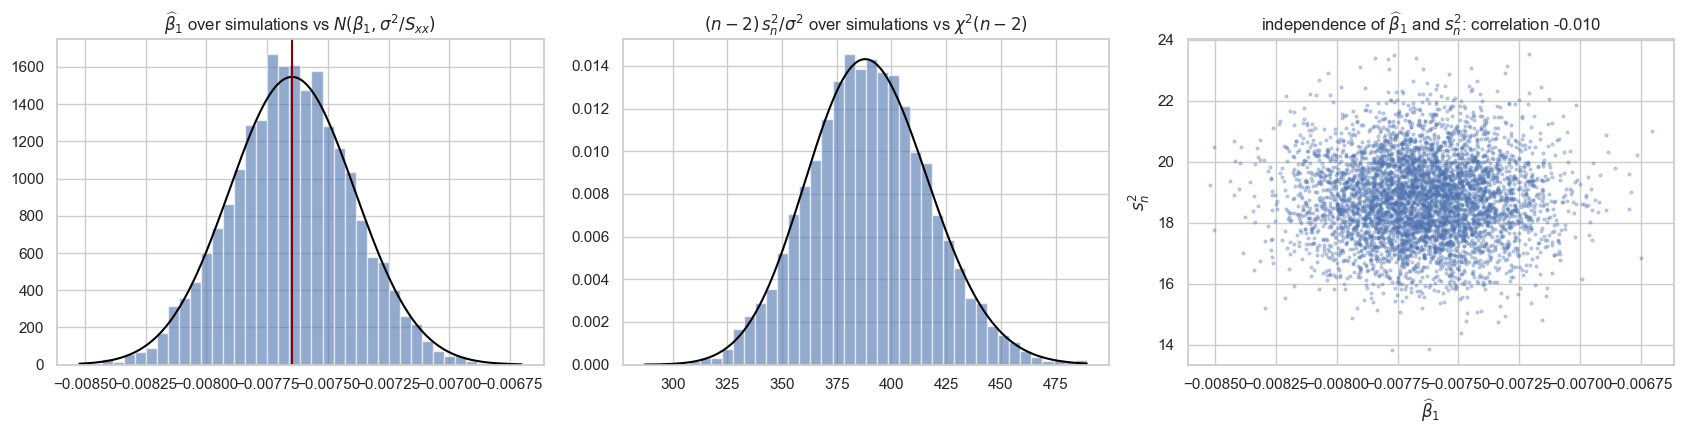

Share of 95% t-intervals for beta1 that cover the true value under the current settings: 0.958


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].hist(b1_sim, bins=40, density=True, alpha=0.6)
grid = np.linspace(b1_sim.min(), b1_sim.max(), 200)
axes[0].plot(grid, stats.norm.pdf(grid, beta1_true, sigma_true * np.sqrt(delta_1_sim)), color='black')
axes[0].axvline(beta1_true, color='darkred', linewidth=1.5)
axes[0].set_title(r'$\widehat{\beta}_1$ over simulations vs $N(\beta_1, \sigma^2/S_{xx})$')

chi = (n_sim - 2) * s_n2_sim / sigma_true ** 2
axes[1].hist(chi, bins=40, density=True, alpha=0.6)
grid = np.linspace(chi.min(), chi.max(), 200)
axes[1].plot(grid, stats.chi2.pdf(grid, df=n_sim - 2), color='black')
axes[1].set_title(r'$(n-2)\,s_n^2/\sigma^2$ over simulations vs $\chi^2(n-2)$')

axes[2].scatter(b1_sim, s_n2_sim, s=4, alpha=0.3)
axes[2].set_xlabel(r'$\widehat{\beta}_1$')
axes[2].set_ylabel(r'$s_n^2$')
axes[2].set_title(f'independence of $\\widehat{{\\beta}}_1$ and $s_n^2$: correlation {np.corrcoef(b1_sim, s_n2_sim)[0, 1]:.3f}')

plt.tight_layout()
plt.show()

# quick check of the t-interval under the current settings (details in section 7)
t_q_sim = stats.t.ppf(0.975, df=n_sim - 2)
se1_sim = np.sqrt(s_n2_sim * delta_1_sim)
covers = (b1_sim - t_q_sim * se1_sim <= beta1_true) & (beta1_true <= b1_sim + t_q_sim * se1_sim)
print(f"Share of 95% t-intervals for beta1 that cover the true value under the current settings: {covers.mean():.3f}")

## 6. Gauss–Markov theorem at work
A **linear estimator** (lineární odhad) of a parameter is a statistic of the form $\sum_i c_i Y_i$ with fixed constants $c_i$. The Gauss–Markov theorem says: if the errors in model $(\ast)$ are uncorrelated with $\mathrm{E}\,e_i = 0$ and the same variance $\sigma^2$ (no normality needed), then among all linear **unbiased** (nestranné) estimators the least squares estimates have the smallest variance; they are **BLUE**, best linear unbiased estimators (nejlepší lineární nestranné odhady). The proof in the lecture notes finds the optimal weights $c_i = (x_i - \overline{x})/S_{xx}$, exactly the weights in the identity $\widehat{\beta}_1 = \sum_i (x_i - \overline{x})\, y_i / S_{xx}$ from the board exercise of Exercise 01. The lecture also warns that for clearly non-normal errors a *non-linear* or *biased* estimator can beat least squares; that is the starting point of robust regression later in the course.

To see what the theorem means, we build a competitor: split the cars into a light half and a heavy half (by the median weight) and estimate the slope by the line through the two group means,

$$\widetilde{\beta}_1 = \frac{\overline{Y}_H - \overline{Y}_L}{\overline{x}_H - \overline{x}_L}$$

(Wald's grouping estimator). It is linear in the $Y_i$ and unbiased, because $\mathrm{E}\,\overline{Y}_H - \mathrm{E}\,\overline{Y}_L = \beta_1 (\overline{x}_H - \overline{x}_L)$, and its variance is $\sigma^2 (1/n_H + 1/n_L)/(\overline{x}_H - \overline{x}_L)^2$. Gauss–Markov predicts that this variance is larger than $\sigma^2/S_{xx}$; the simulation confirms it.

In [14]:
# uses the simulated samples and the design of section 5 (so the settings chosen there apply here too)
median_x = np.median(x_design)
low, high = x_design <= median_x, x_design > median_x
n_L, n_H = int(low.sum()), int(high.sum())
xbar_L, xbar_H = x_design[low].mean(), x_design[high].mean()

b1_wald_sim = (Y_sim[:, high].mean(axis=1) - Y_sim[:, low].mean(axis=1)) / (xbar_H - xbar_L)
var_wald_theory = sigma_true ** 2 * (1 / n_H + 1 / n_L) / (xbar_H - xbar_L) ** 2

comparison = pd.DataFrame({
    'estimator': ['least squares', "Wald's grouping estimator"],
    'mean over simulations': [b1_sim.mean(), b1_wald_sim.mean()],
    'true beta1': [beta1_true, beta1_true],
    'variance over simulations': [b1_sim.var(ddof=1), b1_wald_sim.var(ddof=1)],
    'theoretical variance (normal, independent errors)': [sigma_true ** 2 / S_xx_sim, var_wald_theory],
})
print(f"variance ratio (grouping / least squares): {var_wald_theory / (sigma_true ** 2 / S_xx_sim):.2f}")
comparison

variance ratio (grouping / least squares): 1.42


,estimator,mean over simulations,true beta1,variance over simulations,"theoretical variance (normal, independent errors)"
0,least squares,-0.0076,-0.0076,6.3216e-08,6.6545e-08
1,Wald's grouping estimator,-0.0076,-0.0076,8.8348e-08,9.4432e-08


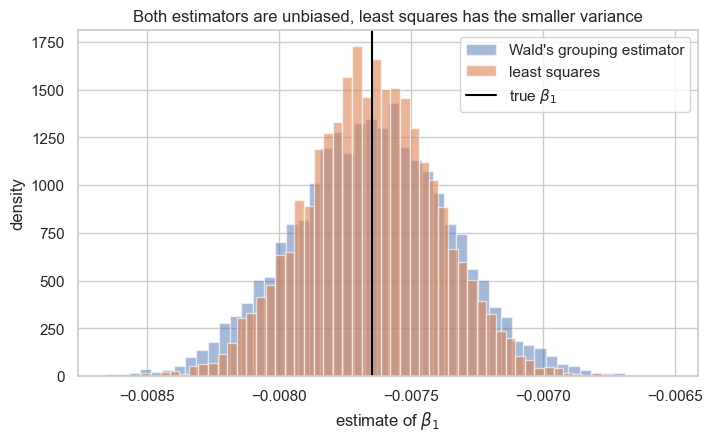

In [15]:
plt.figure(figsize=(8, 4.5))
plt.hist(b1_wald_sim, bins=50, density=True, alpha=0.5, label="Wald's grouping estimator")
plt.hist(b1_sim, bins=50, density=True, alpha=0.6, label='least squares')
plt.axvline(beta1_true, color='black', linewidth=1.5, label=r'true $\beta_1$')
plt.xlabel(r'estimate of $\beta_1$')
plt.ylabel('density')
plt.title('Both estimators are unbiased, least squares has the smaller variance')
plt.legend()
plt.show()

## 7. Confidence intervals for $\beta_0$ and $\beta_1$
A **confidence interval** (CI; Czech: interval spolehlivosti, IS) gives a measure of precision of a point estimate. For normal errors (and approximately otherwise, because the least squares estimates are linear in the $Y_i$ and the central limit theorem applies)

$$T_j = \frac{\widehat{\beta}_j - \beta_j}{\widehat{\sigma}(\widehat{\beta}_j)} \sim t(n-2), \qquad j = 0, 1,$$

so the $100(1-\alpha)\,\%$ confidence interval is $\widehat{\beta}_j \pm t_{1-\alpha/2}(n-2)\, \widehat{\sigma}(\widehat{\beta}_j)$. We compute the intervals by hand with the $t$ quantile from `scipy` and compare them with `model.conf_int()` (R: `confint(mod)`), which is also the last pair of columns in the summary table. With 390 degrees of freedom the $t$ quantile is practically the normal one, 1.966 vs 1.960.

Interpretation of the slope interval: with 95 % confidence, every extra 1000 lb costs between roughly 7.1 and 8.2 mpg. As the lecture remarks, the interval for the intercept is the wider one in absolute terms (about 3 mpg against 0.001 mpg per lb), so the slope is estimated more precisely than the intercept; relative to the size of the estimates the picture can be the other way round, as it is here. The intercept interval also describes a car of weight zero, which does not exist.

The two intervals are constructed separately, each with confidence $1-\alpha$; a *simultaneous* confidence region for $(\beta_0, \beta_1)$ (a rectangle or an ellipse in the plane) is a different object and will be discussed with multiple regression.

In [16]:
alpha = 0.05
t_q = stats.t.ppf(1 - alpha / 2, df=n - 2)      # R: qt(0.975, n - 2)
print(f"t quantile t_(1 - alpha/2)(n - 2) = t_0.975({n - 2}) = {t_q:.4f}   (normal quantile: {stats.norm.ppf(0.975):.4f})")

ci_manual = pd.DataFrame({
    'lower': [beta0_hat - t_q * se_beta0, beta1_hat - t_q * se_beta1],
    'upper': [beta0_hat + t_q * se_beta0, beta1_hat + t_q * se_beta1],
}, index=['Intercept', 'weight'])
print("\nmanual 95% confidence intervals:")
print(ci_manual)
print("\nstatsmodels conf_int (R: confint(mod)):")
print(model.conf_int(alpha=0.05))
print(f"\nslope per 1000 lb: ({1000 * ci_manual.loc['weight', 'lower']:.2f}, {1000 * ci_manual.loc['weight', 'upper']:.2f}) mpg")

t quantile t_(1 - alpha/2)(n - 2) = t_0.975(390) = 1.9661   (normal quantile: 1.9600)

manual 95% confidence intervals:
             lower    upper
Intercept  44.6463  47.7868
weight     -0.0082  -0.0071

statsmodels conf_int (R: confint(mod)):
                 0        1
Intercept  44.6463  47.7868
weight     -0.0082  -0.0071

slope per 1000 lb: (-8.15, -7.14) mpg


### What "95 % confidence" means
The interval is random, the parameter is not. In repeated sampling 95 % of the intervals cover the true $\beta_1$; a particular interval either does or does not. We check the coverage on the simulated samples of section 5 and draw the first hundred intervals.

Share of the 5000 simulated 95% intervals that cover the true beta1: 0.958


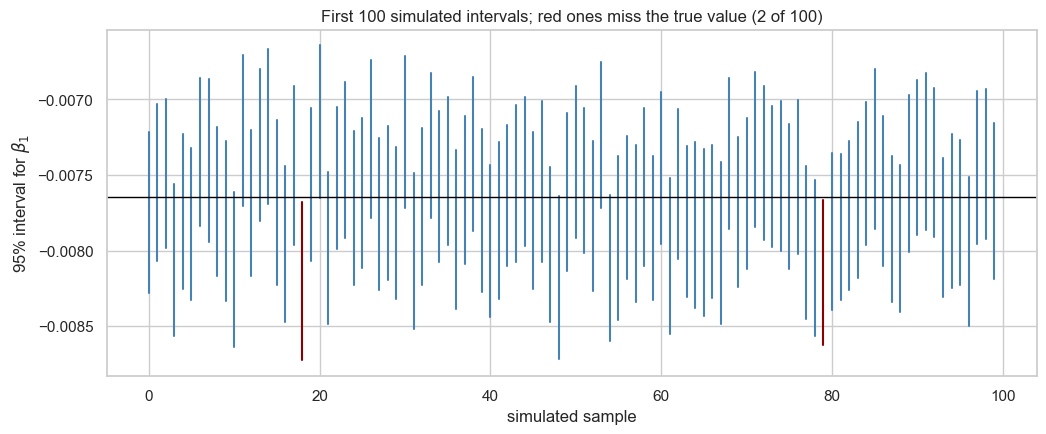

In [17]:
# uses the simulated samples of section 5, so the settings chosen there apply here too
t_q_sim = stats.t.ppf(0.975, df=n_sim - 2)
se1_sim = np.sqrt(s_n2_sim * delta_1_sim)
lower_sim = b1_sim - t_q_sim * se1_sim
upper_sim = b1_sim + t_q_sim * se1_sim
covers = (lower_sim <= beta1_true) & (beta1_true <= upper_sim)
print(f"Share of the {reps} simulated 95% intervals that cover the true beta1: {covers.mean():.3f}")

k = 100
plt.figure(figsize=(12, 4.5))
for i in range(k):
    plt.plot([i, i], [lower_sim[i], upper_sim[i]], color='steelblue' if covers[i] else 'darkred', linewidth=1.5)
plt.axhline(beta1_true, color='black', linewidth=1)
plt.xlabel('simulated sample')
plt.ylabel(r'95% interval for $\beta_1$')
plt.title(f'First {k} simulated intervals; red ones miss the true value ({(~covers[:k]).sum()} of {k})')
plt.show()

## 8. Tests about $\beta_0$ and $\beta_1$
A **hypothesis test** (test hypotéz) at **significance level** $\alpha$ (hladina významnosti) rejects the **null hypothesis** $H_0$ (nulová hypotéza) when the test statistic falls into the **critical region** (kritický obor). The lecture builds the tests from the confidence intervals: $H_0: \beta_j = b$ is rejected exactly when $b$ lies outside the $100(1-\alpha)\,\%$ interval.

**Is weight useful at all?** $H_0: \beta_1 = 0$ against $H_1: \beta_1 \neq 0$ decides between the models $Y_i = \beta_0 + e_i$ and $Y_i = \beta_0 + \beta_1 x_i + e_i$. Reject when

$$|T_1| = \frac{|\widehat{\beta}_1|}{\widehat{\sigma}(\widehat{\beta}_1)} = |\widehat{\beta}_1| \frac{\sqrt{S_{xx}}}{s_n} > t_{1-\alpha/2}(n-2).$$

Intuitively, $|T_1|$ is the reciprocal of the relative error $\widehat{\sigma}(\widehat{\beta}_1)/|\widehat{\beta}_1|$ of the estimate: we reject $H_0$ when the slope is estimated with a small relative error.

**Does the line pass through the origin?** $H_0: \beta_0 = 0$, reject when $|T_0| = |\widehat{\beta}_0|/\widehat{\sigma}(\widehat{\beta}_0) > t_{1-\alpha/2}(n-2)$. Not rejecting would mean that the simpler model $Y_i = \beta_1 x_i + e_i$ describes the data adequately.

**A given candidate value.** $H_0: \beta_1 = b_1$ with $|T| = |\widehat{\beta}_1 - b_1| / \widehat{\sigma}(\widehat{\beta}_1)$. As a candidate we take $b_1 = -0.0075$, "a loss of 7.5 mpg per 1000 lb", which lies inside the confidence interval, and $b_1 = -0.01$, which lies outside.

The **$p$-value** (p-hodnota) $2\,P(t(n-2) > |T|)$ is the smallest level at which $H_0$ would still be rejected; the lecture works with critical values, R and `statsmodels` report $p$-values. `statsmodels` gives $T$ and the $p$-value in the columns `t` and `P>|t|` (for the hypotheses $\beta_j = 0$), and `model.t_test('weight = -0.0075')` handles a general value. Remember the lecture's warning: not rejecting $\beta_1 = 0$ does not prove that $x$ is useless (the relationship may be non-linear), and rejecting it only says that there is a linear trend.

**Duality with the confidence interval.** Check on the two candidate values that $H_0: \beta_1 = b_1$ is rejected exactly when $b_1$ lies outside the 95 % interval of section 7.

In [18]:
T1 = beta1_hat / se_beta1
T0 = beta0_hat / se_beta0
p1 = 2 * stats.t.sf(abs(T1), df=n - 2)
p0 = 2 * stats.t.sf(abs(T0), df=n - 2)
print(f"critical value t_0.975({n - 2}) = {t_q:.3f}")
print(f"H0: beta1 = 0   |T1| = {abs(T1):7.2f}   p = {p1:.2e}   -> reject H0, weight explains part of the variability of mpg")
print(f"H0: beta0 = 0   |T0| = {abs(T0):7.2f}   p = {p0:.2e}   -> reject H0, the line does not pass through the origin")
print()
for b1_candidate in (-0.0075, -0.01):
    T = (beta1_hat - b1_candidate) / se_beta1
    p = 2 * stats.t.sf(abs(T), df=n - 2)
    inside = ci_manual.loc['weight', 'lower'] <= b1_candidate <= ci_manual.loc['weight', 'upper']
    verdict = 'do not reject' if p > alpha else 'reject'
    print(f"H0: beta1 = {b1_candidate:<8}  T = {T:7.3f}   p = {p:.2e}   -> {verdict}; inside the 95% CI: {inside}")

critical value t_0.975(390) = 1.966
H0: beta1 = 0   |T1| =   29.65   p = 6.02e-102   -> reject H0, weight explains part of the variability of mpg
H0: beta0 = 0   |T0| =   57.87   p = 1.62e-193   -> reject H0, the line does not pass through the origin

H0: beta1 = -0.0075   T =  -0.571   p = 5.68e-01   -> do not reject; inside the 95% CI: True
H0: beta1 = -0.01     T =   9.120   p = 4.04e-18   -> reject; inside the 95% CI: False


In [19]:
# statsmodels: the summary table gives T and p for beta_j = 0; t_test handles any value
print(model.summary().tables[1])
print()
print(model.t_test('weight = -0.0075'))       # R: linearHypothesis(mod, "weight = -0.0075") from package car

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     46.2165      0.799     57.867      0.000      44.646      47.787
weight        -0.0076      0.000    -29.645      0.000      -0.008      -0.007

                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0076      0.000     -0.571      0.568      -0.008      -0.007


### One-sided alternative
The lecture treats two-sided alternatives; the one-sided version is the same machinery. If the question is whether heavier cars are *less* efficient, the alternative is one-sided, $H_1: \beta_1 < 0$, the critical region is $T_1 < -t_{1-\alpha}(n-2)$, and the $p$-value is $P(t(n-2) < T_1)$, half of the two-sided one. The one-sided test rejects more easily in the direction that was specified in advance; the direction must not be chosen after looking at the sign of the estimate.

In [20]:
p_one_sided = stats.t.cdf(T1, df=n - 2)          # H1: beta1 < 0
print(f"one-sided p-value (H1: beta1 < 0): {p_one_sided:.2e}, two-sided: {p1:.2e}")

one-sided p-value (H1: beta1 < 0): 3.01e-102, two-sided: 6.02e-102


## 9. Reading the `statsmodels` summary
After Lecture 2 the coefficient table is fully readable:

| column | meaning | by hand |
|---|---|---|
| `coef` | $\widehat{\beta}_j$ | formula (2.1) |
| `std err` | $\widehat{\sigma}(\widehat{\beta}_j)$ | $s_n\sqrt{\delta_j}$ |
| `t` | $T_j = \widehat{\beta}_j / \widehat{\sigma}(\widehat{\beta}_j)$ for $H_0: \beta_j = 0$ | |
| `P>\|t\|` | two-sided $p$-value from $t(n-2)$ | `2 * stats.t.sf(abs(T), n - 2)` |
| `[0.025  0.975]` | 95 % confidence interval | $\widehat{\beta}_j \pm t_{0.975}(n-2)\,\widehat{\sigma}(\widehat{\beta}_j)$ |

`Df Residuals` is $n - 2$ and `model.scale` is $s_n^2$. The remaining entries (`R-squared`, `F-statistic`, `Log-Likelihood`, `AIC`, `BIC`, `Omnibus`, `Durbin-Watson`, ...) belong to later lectures; `R-squared` and the $F$-test come next week with the ANOVA table.

In [21]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     878.8
Date:                Mon, 05 Oct 2026   Prob (F-statistic):          6.02e-102
Time:                        00:40:21   Log-Likelihood:                -1130.0
No. Observations:                 392   AIC:                             2264.
Df Residuals:                     390   BIC:                             2272.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     46.2165      0.799     57.867      0.0

## 10. The lecture example, continued: speed of sound vs temperature
Lecture 2 finishes the five-point example with 95 % confidence intervals $(323.5, 338.8)$ for $\beta_0$ and $(0.414, 0.709)$ for $\beta_1$, using $t_{0.975}(3) = 3.18$, and with the tests $|T_0| = 138.3$ and $|T_1| = 12.1$, both far above 3.18. We reproduce all four numbers and compare with `conf_int` and the summary.

In [22]:
sound = pd.DataFrame({'temperature': [-20, 0, 20, 50, 100],
                      'speed': [323, 327, 340, 364, 386]})
sound_model = smf.ols('speed ~ temperature', data=sound).fit()

m = len(sound)
t_q3 = stats.t.ppf(0.975, df=m - 2)
b0, b1 = sound_model.params['Intercept'], sound_model.params['temperature']
se0, se1 = sound_model.bse['Intercept'], sound_model.bse['temperature']

print(f"t_0.975({m - 2}) = {t_q3:.2f}")
print(f"95% CI for beta0: ({b0 - t_q3 * se0:.1f}, {b0 + t_q3 * se0:.1f})     slide: (323.5, 338.8)")
print(f"95% CI for beta1: ({b1 - t_q3 * se1:.3f}, {b1 + t_q3 * se1:.3f})   slide: (0.414, 0.709)")
print(f"|T0| = {abs(b0 / se0):.2f}   slide: 138.3 (rounded down from 138.35)")
print(f"|T1| = {abs(b1 / se1):.2f}    slide: 12.1")
print()
print(sound_model.conf_int(alpha=0.05))

t_0.975(3) = 3.18
95% CI for beta0: (323.5, 338.8)     slide: (323.5, 338.8)
95% CI for beta1: (0.414, 0.709)   slide: (0.414, 0.709)
|T0| = 138.35   slide: 138.3 (rounded down from 138.35)
|T1| = 12.10    slide: 12.1

                    0         1
Intercept    323.5415  338.7767
temperature    0.4137    0.7091


## 11. Individual work
Work in the `cars` data frame. Write a short conclusion after each step.

1. Convert fuel efficiency to litres per 100 km, $\text{L/100km} = 235.215/\text{mpg}$, and engine power to kilowatts, $\text{kW} = 0.7457 \cdot \text{hp}$ (1 mechanical horsepower = 745.7 W). Add both as new columns and summarise them.
2. Fit the simple linear regression of `l_per_100km` on `kw` with `statsmodels` and plot the data with the fitted line. Interpret $\widehat{\beta}_1$ in words (litres per 100 km per 10 kW).
3. Recompute $\widehat{\beta}_0, \widehat{\beta}_1, s_n$ and both standard errors by hand and check them against the summary.
4. Give the 95 % confidence interval for $\beta_1$ by hand and with `conf_int`. Is a slope of 0.1 L/100 km per kW, that is one litre per 100 km for every 10 kW, compatible with the data? And a slope of 0.12? Answer each question once with the interval and once with the test $H_0: \beta_1 = b_1$, and check that the two answers agree.
5. Test $H_0: \beta_0 = 0$. What would a model through the origin claim about a car with zero power, and is the test the right tool to decide whether such a model makes sense?
6. Compute the 99 % interval for $\beta_1$. How does its width compare with the 95 % interval, and why?
7. Repeat step 4 for European cars only. Compare the two intervals for $\beta_1$ (all cars vs Europe): do they overlap, and what would you conclude cautiously? (A formal comparison of slopes between groups comes later in the course.)

In [23]:
# your solution


## 12. What to remember
- The least squares estimates are unbiased with $\mathrm{Var}(\widehat{\beta}_1) = \sigma^2/S_{xx}$; more spread in $x$ (larger $S_{xx}$) means a more precise slope. Simulation from a known model is the way to *see* sampling distributions.
- $s_n^2$ is unbiased for $\sigma^2$, $(n-2)s_n^2/\sigma^2 \sim \chi^2(n-2)$ for normal errors, and $s_n^2$ is independent of $\widehat{\beta}_0, \widehat{\beta}_1$; this is what makes the $t$ ratios exactly $t(n-2)$.
- Gauss–Markov: any other linear unbiased estimator of the slope has a larger variance; the grouping estimator was a concrete example.
- Confidence interval $\widehat{\beta}_j \pm t_{1-\alpha/2}(n-2)\,\widehat{\sigma}(\widehat{\beta}_j)$; test $H_0: \beta_j = b$ by $|T| = |\widehat{\beta}_j - b|/\widehat{\sigma}(\widehat{\beta}_j)$ against $t_{1-\alpha/2}(n-2)$; the two are dual.
- The coefficient table of `summary()` (`coef`, `std err`, `t`, `P>|t|`, confidence limits) is exactly this machinery; `R-squared` and the $F$-test come next week.